In [220]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

In [221]:
df = pd.read_csv(f"tested.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [222]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


## Droping and creating new columns from old one

In [223]:
pass_information = df.drop(columns=["PassengerId"])

In [224]:
pass_information

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [225]:
def extract_status(string,str_to_extract):
    
    for s in str_to_extract:
        if s in string:
            return s
    return ""

titles_list = [
    "Mr", "Mrs", "Miss", "Master", "Ms", "Mme", "Mlle", 
    "Dr", "Rev", "Colonel", "Col", "Major", "Capt", 
    "Sir", "Lady", "the Countess", "Countess", "Don", "Dona", "Jonkheer"
]

pass_information["social_status"]=pass_information['Name'].apply(lambda x:extract_status(x,titles_list))


In [226]:
pass_information.drop(columns="Name",inplace=True)

In [227]:
pass_information

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,social_status
0,0,3,male,34.5,0,0,330911,7.8292,NaN,Q,Mr
1,1,3,female,47.0,1,0,363272,7.0000,NaN,S,Mr
2,0,2,male,62.0,0,0,240276,9.6875,NaN,Q,Mr
3,0,3,male,27.0,0,0,315154,8.6625,NaN,S,Mr
4,1,3,female,22.0,1,1,3101298,12.2875,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...
413,0,3,male,NaN,0,0,A.5. 3236,8.0500,NaN,S,Mr
414,1,1,female,39.0,0,0,PC 17758,108.9000,C105,C,Don
415,0,3,male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,Mr
416,0,3,male,NaN,0,0,359309,8.0500,NaN,S,Mr


In [228]:
pass_information.drop(columns="Ticket",inplace=True)

In [229]:
pass_information

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,social_status
0,0,3,male,34.5,0,0,7.8292,NaN,Q,Mr
1,1,3,female,47.0,1,0,7.0000,NaN,S,Mr
2,0,2,male,62.0,0,0,9.6875,NaN,Q,Mr
3,0,3,male,27.0,0,0,8.6625,NaN,S,Mr
4,1,3,female,22.0,1,1,12.2875,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...
413,0,3,male,NaN,0,0,8.0500,NaN,S,Mr
414,1,1,female,39.0,0,0,108.9000,C105,C,Don
415,0,3,male,38.5,0,0,7.2500,NaN,S,Mr
416,0,3,male,NaN,0,0,8.0500,NaN,S,Mr


## Train test split

In [230]:
from sklearn.model_selection import train_test_split
train_set,test_set=train_test_split(pass_information,test_size=0.2,
                                                  random_state=42)

In [231]:
train_set[train_set["Survived"]==1]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,social_status
140,1,3,female,10.0,5,2,46.9000,NaN,S,Miss
18,1,3,female,27.0,1,0,7.9250,NaN,S,Miss
132,1,3,female,NaN,0,4,25.4667,NaN,S,Mr
63,1,3,female,22.0,0,0,7.7250,NaN,Q,Miss
26,1,1,female,22.0,0,1,61.9792,B36,C,Miss
...,...,...,...,...,...,...,...,...,...,...
359,1,3,female,30.0,1,0,15.5500,NaN,S,Mr
87,1,3,female,18.0,0,0,8.0500,NaN,S,Miss
330,1,2,female,48.0,0,2,36.7500,NaN,S,Mr
214,1,3,female,38.0,4,2,7.7750,NaN,S,Miss


In [232]:
X_train=train_set.drop(columns="Survived")
y_train=train_set["Survived"]

In [233]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,social_status
336,2,male,32.0,0,0,13.0000,NaN,S,Mr
31,2,male,24.0,2,0,31.5000,NaN,S,Mr
84,2,male,NaN,0,0,10.7083,NaN,Q,Mr
287,1,male,24.0,1,0,82.2667,B45,S,Mr
317,2,male,19.0,0,0,10.5000,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...
71,3,male,21.0,0,0,7.8958,NaN,S,Mr
106,3,male,21.0,0,0,7.8208,NaN,Q,Mr
270,1,male,46.0,0,0,75.2417,C6,C,Mr
348,2,male,24.0,0,0,13.5000,NaN,S,Mr


In [234]:
y_train.head(40)

336    0
31     0
84     0
287    0
317    0
211    0
94     0
389    0
327    0
5      0
45     0
140    1
145    0
403    0
358    0
16     0
386    0
124    0
325    0
3      0
18     1
132    1
60     0
198    0
332    0
63     1
265    0
193    0
192    0
266    0
196    0
116    0
26     1
7      0
250    1
246    1
108    0
101    0
310    0
29     0
Name: Survived, dtype: int64

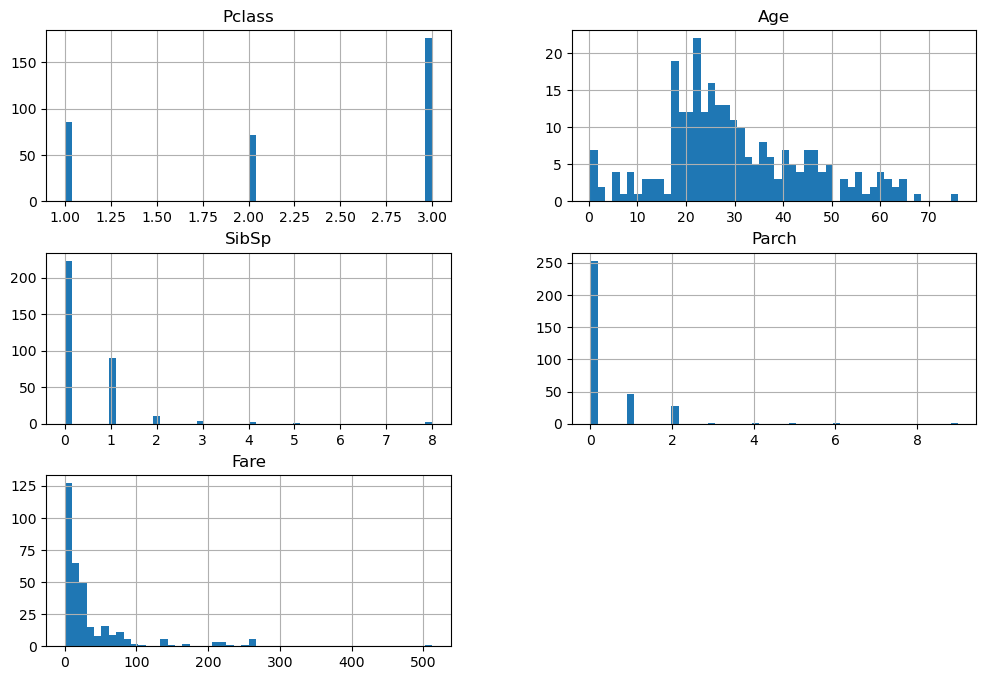

In [235]:
X_train.hist(bins=50,figsize=(12,8))
plt.show()

array([[<AxesSubplot: xlabel='Pclass', ylabel='Pclass'>,
        <AxesSubplot: xlabel='Age', ylabel='Pclass'>,
        <AxesSubplot: xlabel='SibSp', ylabel='Pclass'>,
        <AxesSubplot: xlabel='Fare', ylabel='Pclass'>],
       [<AxesSubplot: xlabel='Pclass', ylabel='Age'>,
        <AxesSubplot: xlabel='Age', ylabel='Age'>,
        <AxesSubplot: xlabel='SibSp', ylabel='Age'>,
        <AxesSubplot: xlabel='Fare', ylabel='Age'>],
       [<AxesSubplot: xlabel='Pclass', ylabel='SibSp'>,
        <AxesSubplot: xlabel='Age', ylabel='SibSp'>,
        <AxesSubplot: xlabel='SibSp', ylabel='SibSp'>,
        <AxesSubplot: xlabel='Fare', ylabel='SibSp'>],
       [<AxesSubplot: xlabel='Pclass', ylabel='Fare'>,
        <AxesSubplot: xlabel='Age', ylabel='Fare'>,
        <AxesSubplot: xlabel='SibSp', ylabel='Fare'>,
        <AxesSubplot: xlabel='Fare', ylabel='Fare'>]], dtype=object)

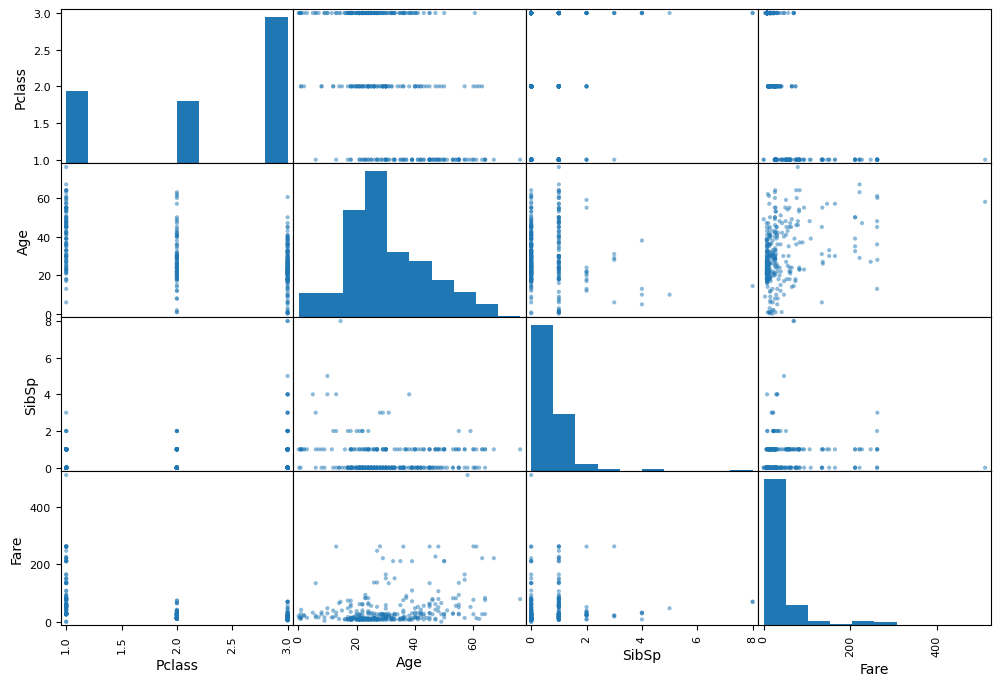

In [236]:
from pandas.plotting import scatter_matrix

attributes = ["Pclass","Age","SibSp","Fare"]

scatter_matrix(pass_information[attributes],figsize=(12,8))

## Data cleaning (imputation)

In [237]:
mean=pass_information["Pclass"].mean()
pass_information["Pclass"].fillna(mean,inplace=True)

In [238]:
median = pass_information["Age"].median()
pass_information["Age"].fillna(median,inplace=True)

In [239]:
mean=pass_information["SibSp"].mean()
pass_information["SibSp"].fillna(mean,inplace=True)

In [240]:
mean=pass_information["Fare"].mean()
pass_information["Fare"].fillna(mean,inplace=True)

array([[<AxesSubplot: xlabel='Pclass', ylabel='Pclass'>,
        <AxesSubplot: xlabel='Age', ylabel='Pclass'>,
        <AxesSubplot: xlabel='SibSp', ylabel='Pclass'>,
        <AxesSubplot: xlabel='Fare', ylabel='Pclass'>],
       [<AxesSubplot: xlabel='Pclass', ylabel='Age'>,
        <AxesSubplot: xlabel='Age', ylabel='Age'>,
        <AxesSubplot: xlabel='SibSp', ylabel='Age'>,
        <AxesSubplot: xlabel='Fare', ylabel='Age'>],
       [<AxesSubplot: xlabel='Pclass', ylabel='SibSp'>,
        <AxesSubplot: xlabel='Age', ylabel='SibSp'>,
        <AxesSubplot: xlabel='SibSp', ylabel='SibSp'>,
        <AxesSubplot: xlabel='Fare', ylabel='SibSp'>],
       [<AxesSubplot: xlabel='Pclass', ylabel='Fare'>,
        <AxesSubplot: xlabel='Age', ylabel='Fare'>,
        <AxesSubplot: xlabel='SibSp', ylabel='Fare'>,
        <AxesSubplot: xlabel='Fare', ylabel='Fare'>]], dtype=object)

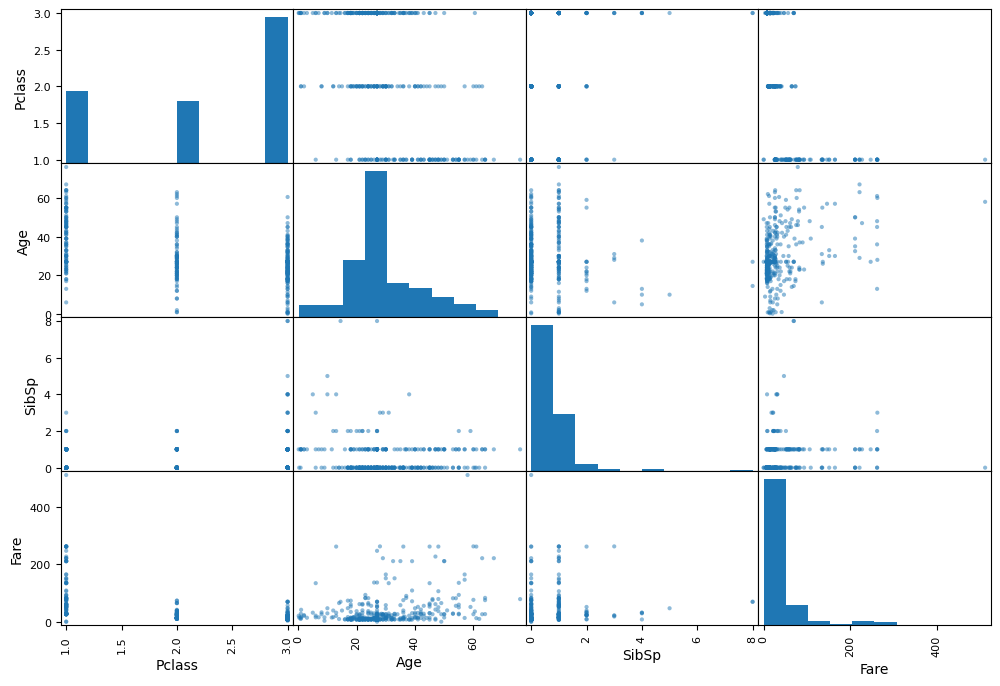

In [241]:
from pandas.plotting import scatter_matrix

attributes = ["Pclass","Age","SibSp","Fare"]

scatter_matrix(pass_information[attributes],figsize=(12,8))

In [242]:
pass_information["Cabin"].fillna(0,inplace=True)

In [257]:
for i in range(len(pass_information["Cabin"])):
    if pass_information.loc[i,"Cabin"] != 0:
        pass_information.loc[i,"Cabin"] = 1

In [258]:
pass_information

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,social_status
0,0,3,male,34.5,0,0,7.8292,0,Q,Mr
1,1,3,female,47.0,1,0,7.0000,0,S,Mr
2,0,2,male,62.0,0,0,9.6875,0,Q,Mr
3,0,3,male,27.0,0,0,8.6625,0,S,Mr
4,1,3,female,22.0,1,1,12.2875,0,S,Mr
...,...,...,...,...,...,...,...,...,...,...
413,0,3,male,27.0,0,0,8.0500,0,S,Mr
414,1,1,female,39.0,0,0,108.9000,1,C,Don
415,0,3,male,38.5,0,0,7.2500,0,S,Mr
416,0,3,male,27.0,0,0,8.0500,0,S,Mr


In [264]:
gender_cat=pass_information[["Sex"]]

In [267]:
from sklearn.preprocessing import OneHotEncoder

gender_cat_encoder=OneHotEncoder()
pass_gender_1hot = gender_cat_encoder.fit_transform(gender_cat)


In [268]:
pass_gender_1hot.toarray()

array([[0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.

In [293]:
pass_information[["female","male"]]=pass_gender_1hot.toarray()

In [295]:
pass_information.drop(columns="Sex",inplace=True)

In [296]:
pass_information

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Embarked,social_status,female,male
0,0,3,34.5,0,0,7.8292,0,Q,Mr,0.0,1.0
1,1,3,47.0,1,0,7.0000,0,S,Mr,1.0,0.0
2,0,2,62.0,0,0,9.6875,0,Q,Mr,0.0,1.0
3,0,3,27.0,0,0,8.6625,0,S,Mr,0.0,1.0
4,1,3,22.0,1,1,12.2875,0,S,Mr,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
413,0,3,27.0,0,0,8.0500,0,S,Mr,0.0,1.0
414,1,1,39.0,0,0,108.9000,1,C,Don,1.0,0.0
415,0,3,38.5,0,0,7.2500,0,S,Mr,0.0,1.0
416,0,3,27.0,0,0,8.0500,0,S,Mr,0.0,1.0


In [304]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
categorical_features=["Embarked", "social_status"]
log_features = ["Fare", "SibSp"]
standard_features = ["Age", "Parch"]


preprocessing = ColumnTransformer([
    
    # dealing log features 
    ("log_and_scale",Pipeline([
        ("log",FunctionTransformer(np.log1p,validate=True)),
        ("scaler",StandardScaler())
    ]),log_features),
    
    # dealing with standar_features
    
    ("standard_scale",StandardScaler(),standard_features),
    
    # dealing with categorical features
        
    ("categorical_features",OneHotEncoder(handle_unknown="ignore"),categorical_features)
    
    
    
])
training_data = preprocessing.fit_transform(pass_information)

In [306]:
training_data

array([[-0.86887454, -0.6336812 ,  0.38623105, ...,  1.        ,
         0.        ,  0.        ],
       [-0.97095786,  1.03851197,  1.37137004, ...,  1.        ,
         0.        ,  0.        ],
       [-0.671162  , -0.6336812 ,  2.55353683, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.93910649, -0.6336812 ,  0.70147553, ...,  1.        ,
         0.        ,  0.        ],
       [-0.84330751, -0.6336812 , -0.20485235, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.13814983,  1.03851197, -0.20485235, ...,  0.        ,
         0.        ,  0.        ]])